<a href="https://colab.research.google.com/github/abdulmm44/Student_dropout_prediction/blob/main/Student_dropout_(37).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. **Problem Statement**
Higher education institutions face significant financial and reputational losses due to student dropout, yet they lack a systematic way to identify which students are likely to drop out before it happens.


## 1.1 Main Research Question

To what extent can academic and socioeconomic indicators predict student dropout risk, and which machine learning model provides the most accurate prediction of dropout among higher education students?

Sub-Questions

1. Which academic factors are most strongly associated with student dropout?

2. Which socioeconomic factors are most strongly associated with student dropout?

3. How do different machine learning algorithms perform in predicting student dropout

4. Which machine learning model achieves the highest predictive performance based on Accuracy, Precision, Recall, F1-Score, and ROC-AUC?

5. What are the most important features contributing to dropout prediction?









## 2. **Exploratory Data Analysis:** Data Loading,  Cleaning and Inspection


**Research Questions**
1. What characteristics distinguish dropouts from graduates?
2. Which features appear most predictive?
3. Are there highly correlated variables?
4. Are there potential issues for modeling?
5. What insights can be reported in the final paper?

In [228]:
# Importing the necessary libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    mutual_info_classif,
    RFE
)

# PCA
from sklearn.decomposition import PCA

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [229]:
#Reads the dataset from Github
df = pd.read_csv("https://raw.githubusercontent.com/abdulmm44/Student_dropout_prediction/refs/heads/main/data.csv", sep=';')

In [230]:
# understand the data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [231]:
# First five row
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [232]:
df.shape

(4424, 37)

# Interpretation

We have:

- 4424 student records
- 36 predictor variables
- 1 target variable (Target)

In [233]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [234]:
# check for the missing data
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [235]:
# dictionary mapping the old, messy names to new, clean names
# Format is {'Old Name': 'new_name'}
rename_mapping = {
    'Marital status': 'marital_status',
    'Application mode': 'app_mode',
    'Application order': 'app_order',
    'Daytime/evening attendance\t': 'daytime_attendance',
    'Previous qualification': 'prev_qual',
    'Previous qualification (grade)': 'prev_qual_grade',
    'Admission grade': 'admission_grade',
    'Nacionality': 'nationality',  # Fixing the spelling error
    "Mother's qualification": 'mother_qual',
    "Father's qualification": 'father_qual',
    "Mother's occupation": 'mother_occ',
    "Father's occupation": 'father_occ',
    'Educational special needs': 'special_needs',
    'Tuition fees up to date': 'tuition_current',
    'Scholarship holder': 'scholarship',
    'Age at enrollment': 'age',

    #  extremely long academic performance columns
    'Curricular units 1st sem (credited)': 'sem1_credited',
    'Curricular units 1st sem (enrolled)': 'sem1_enrolled',
    'Curricular units 1st sem (evaluations)': 'sem1_evals',
    'Curricular units 1st sem (approved)': 'sem1_approved',
    'Curricular units 1st sem (grade)': 'sem1_grade',
    'Curricular units 1st sem (without evaluations)': 'sem1_no_evals',

    'Curricular units 2nd sem (credited)': 'sem2_credited',
    'Curricular units 2nd sem (enrolled)': 'sem2_enrolled',
    'Curricular units 2nd sem (evaluations)': 'sem2_evals',
    'Curricular units 2nd sem (approved)': 'sem2_approved',
    'Curricular units 2nd sem (grade)': 'sem2_grade',
    'Curricular units 2nd sem (without evaluations)': 'sem2_no_evals',

    'Unemployment rate': 'unemployment_rate',
    'Inflation rate': 'inflation_rate',
    'GDP': 'gdp',
    'Target': 'target'
}

# Apply the renaming to both our machine dataset (df)
# inplace=True means it updates the dataframe directly without needing to reassign it
df.rename(columns=rename_mapping, inplace=True)

# Verify the changes
print(df.columns)

Index(['marital_status', 'app_mode', 'app_order', 'Course',
       'daytime_attendance', 'prev_qual', 'prev_qual_grade', 'nationality',
       'mother_qual', 'father_qual', 'mother_occ', 'father_occ',
       'admission_grade', 'Displaced', 'special_needs', 'Debtor',
       'tuition_current', 'Gender', 'scholarship', 'age', 'International',
       'sem1_credited', 'sem1_enrolled', 'sem1_evals', 'sem1_approved',
       'sem1_grade', 'sem1_no_evals', 'sem2_credited', 'sem2_enrolled',
       'sem2_evals', 'sem2_approved', 'sem2_grade', 'sem2_no_evals',
       'unemployment_rate', 'inflation_rate', 'gdp', 'target'],
      dtype='object')



Percentages:

target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64 




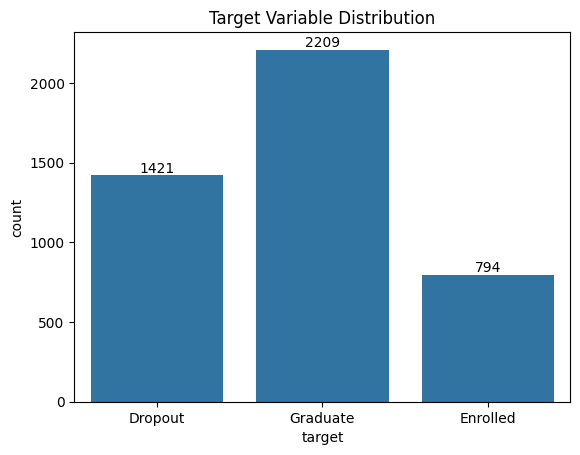

In [236]:
# Target variable analysis - Target Distribution
df['target'].value_counts()

print("\nPercentages:\n")
print(round(df["target"].value_counts(normalize=True)*100,2), "\n\n")

ax = sns.countplot(x='target',data=df)
plt.title('Target Variable Distribution')

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

In [237]:
df

,marital_status,app_mode,app_order,Course,daytime_attendance,prev_qual,prev_qual_grade,nationality,mother_qual,father_qual,...,sem2_credited,sem2_enrolled,sem2_evals,sem2_approved,sem2_grade,sem2_no_evals,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [238]:
# Remove students with unresolved outcomes [Enrolled]

df_model = df[df["target"] != "Enrolled"].copy()

print(f"Original Shape: {df.shape}")
print(f"New Shape: {df_model.shape}")

Original Shape: (4424, 37)
New Shape: (3630, 37)


## **Justification of Removing `Enrolled`**

Students classified as `"Enrolled"` were removed from the analysis because their academic outcome remains unresolved. Retaining them would introduce uncertainty into the target variable and potentially bias the predictive models. Therefore, only students with definitive outcomes (`Graduate or Dropout`) were considered.

Target Counts:
target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Percentages:
target
Graduate    60.85
Dropout     39.15
Name: proportion, dtype: float64


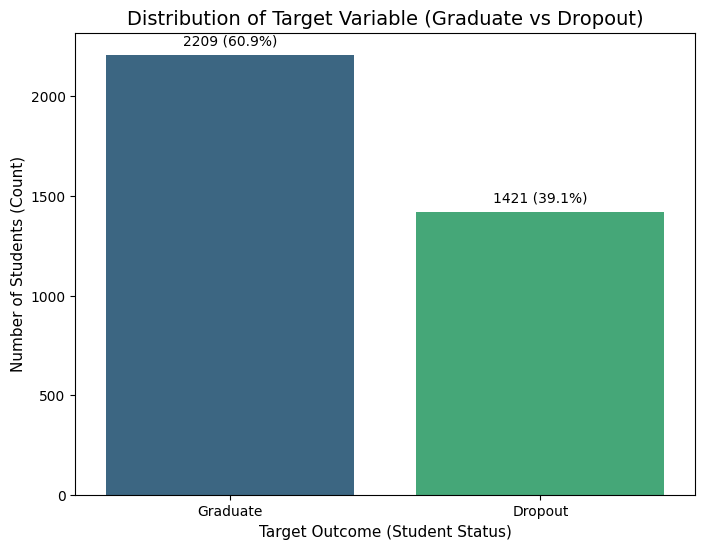

In [239]:
# Verifying Remaining Classes
target_counts = df_model["target"].value_counts()
target_percentages = round(df_model["target"].value_counts(normalize=True) * 100, 2)

print("Target Counts:")
print(target_counts)

print("\nPercentages:")
print(target_percentages)

# Plotting the distribution
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Distribution of Target Variable (Graduate vs Dropout)', fontsize=14)
plt.xlabel('Target Outcome (Student Status)', fontsize=11)
plt.ylabel('Number of Students (Count)', fontsize=11)

# Add count and percentage labels on top of each bar
for i, p in enumerate(ax.patches):
    height = p.get_height()
    outcome_x = p.get_x() + p.get_width() / 2.
    count = int(height)
    # Get the category name using the index 'i'
    category_name = target_counts.index[i]
    percentage = target_percentages[category_name]
    ax.annotate(f'{count} ({percentage:.1f}%)', (outcome_x, height),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.show()

In [240]:
# changing target variable into binary numerical
df_model['target'] = df_model['target'].replace({
    'Dropout': 1,
    'Graduate': 0
})

print(df_model['target'].value_counts())

print("\nUnique Values:")
print(df_model["target"].unique())


target
0    2209
1    1421
Name: count, dtype: int64

Unique Values:
[1 0]


In [241]:
df_model[df_model.target == 0]

,marital_status,app_mode,app_order,Course,daytime_attendance,prev_qual,prev_qual_grade,nationality,mother_qual,father_qual,...,sem2_credited,sem2_enrolled,sem2_evals,sem2_approved,sem2_grade,sem2_no_evals,unemployment_rate,inflation_rate,gdp,target
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,0
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4417,1,1,1,9070,1,1,132.0,1,1,1,...,0,6,6,6,13.500000,0,16.2,0.3,-0.92,0
4418,1,44,1,9070,1,39,120.0,1,3,38,...,5,9,10,7,13.142857,1,16.2,0.3,-0.92,0
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,0
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,0


## **Target Transformation Summary**


Students with unresolved academic outcomes `"Enrolled"` were excluded from the analysis. This reduced the dataset from **4,424 to 3,630 observations**. The target variable was then transformed into a binary classification problem, where Graduate was encoded as 0 and Dropout as 1. The resulting class distribution was approximately 61% graduates and 39% dropouts, indicating only a mild class imbalance that does not require resampling techniques at this stage.

In [242]:
# the copy of our dataset
df_eda = df_model.copy()
# 3. mapping dictionaries based on the dataset's documentation
gender_map = {1: 'Male', 0: 'Female'}
yes_no_map = {1: 'Yes', 0: 'No'}
marital_status_map = {
    1: 'Single', 2: 'Married', 3: 'Widower',
    4: 'Divorced', 5: 'Facto Union', 6: 'Legally Separated'
}

# 4. Decode the numeric data back into readable text
df_eda['Gender'] = df_eda['Gender'].map(gender_map)
df_eda['daytime_attendance'] = df_eda['daytime_attendance'].map(yes_no_map)
df_eda['special_needs'] = df_eda['special_needs'].map(yes_no_map)
df_eda['scholarship'] = df_eda['scholarship'].map(yes_no_map)
df_eda['Displaced'] = df_eda['Displaced'].map(yes_no_map)
df_eda['Debtor'] = df_eda['Debtor'].map(yes_no_map)
df_eda['tuition_current'] = df_eda['tuition_current'].map(yes_no_map)
df_eda['marital_status'] = df_eda['marital_status'].map(marital_status_map)

# decode the nationalities
# Group Nationality (1 = Portuguese, everything else = International)
df_eda['nationality_group'] = df_eda['nationality'].apply(
    lambda x: 'Portuguese' if x == 1 else 'International'
)

# Created the new colum to save the target categorical data
# convert numerical back to categorical target variable

df_eda['target'] = df_eda['target'].replace({
    1 : 'Dropout',
    0 : 'Graduate'

})

# Display the newly decoded features next to the new 'target' variable
cols_to_show = ['Gender', 'marital_status', 'scholarship', 'Debtor','special_needs','daytime_attendance', 'tuition_current','nationality_group', 'target']
print(df_eda[cols_to_show].head())

   Gender marital_status scholarship Debtor special_needs daytime_attendance  \
0    Male         Single          No     No            No                Yes   
1    Male         Single          No     No            No                Yes   
2    Male         Single          No     No            No                Yes   
3  Female         Single          No     No            No                Yes   
4  Female        Married          No     No            No                 No   

  tuition_current nationality_group    target  
0             Yes        Portuguese   Dropout  
1              No        Portuguese  Graduate  
2              No        Portuguese   Dropout  
3             Yes        Portuguese  Graduate  
4             Yes        Portuguese  Graduate  


- ===> Finalise Cateogorical and Numerical Features
- ===> Academic Features
- ===> Socioeconomic Features

In [243]:
# Compare numerical features by outcome

# Select only numerical columns before grouping and calculating the mean
numerical_cols_eda = df_eda.select_dtypes(include=np.number).columns

df_eda.groupby("target")[numerical_cols_eda].mean().T

target,Dropout,Graduate
app_mode,23.712878,15.018108
app_order,1.593244,1.851064
Course,8755.629838,8917.248076
prev_qual,5.311049,4.031236
prev_qual_grade,131.114075,134.082707
nationality,1.957072,1.745134
mother_qual,21.035186,19.311453
father_qual,22.683322,22.499774
mother_occ,10.116115,10.153010
father_occ,10.141450,10.373925


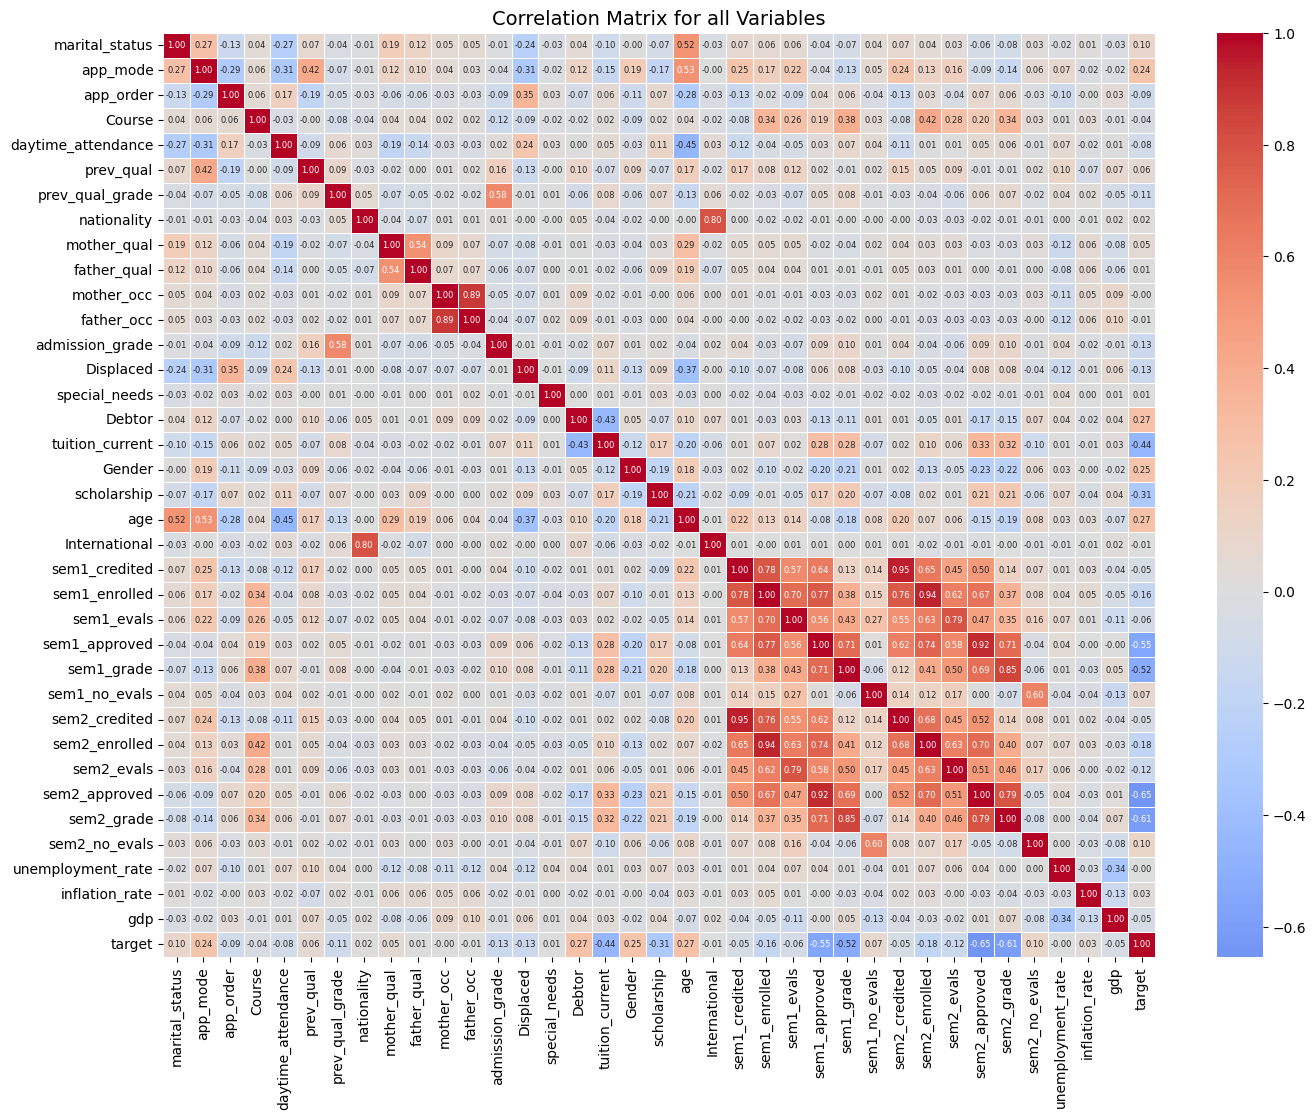

In [244]:
# Correlation Matrix for All Variables
plt.figure(figsize=(16,12))

corr_matrix = df_model.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    center=0,
    annot_kws={'fontsize': 6}
)

plt.title("Correlation Matrix for all Variables", fontsize = 14)
plt.show()

## Correlation Matrix for All Variables
It helps you understand not just how features relate to the target, but also how features relate to each other (e.g., if two independent variables are highly correlated, which could indicate multicollinearity).

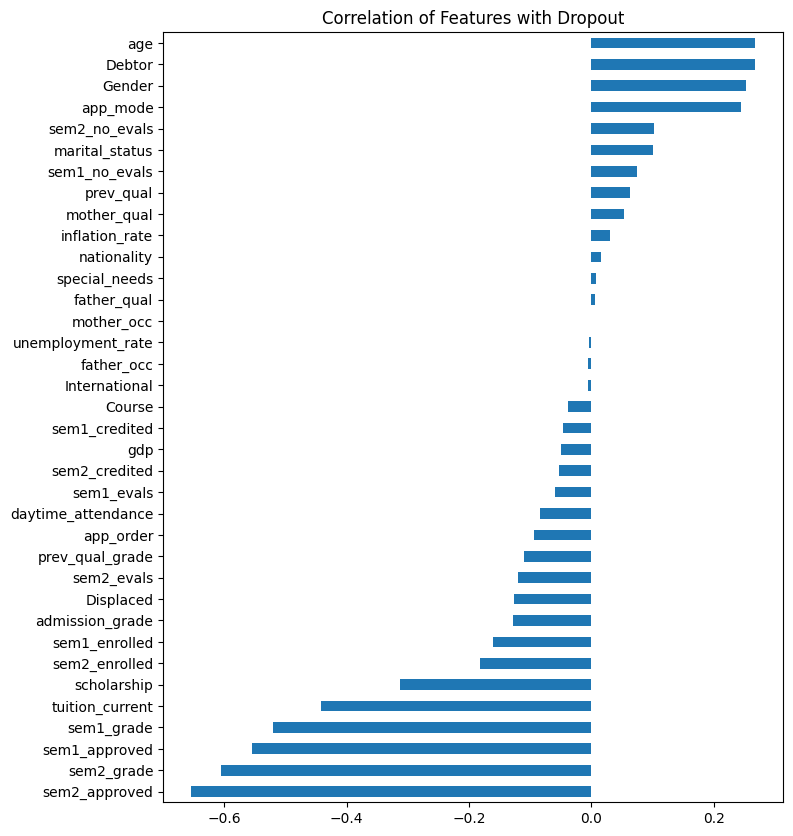

In [245]:
# Correlation with target

corr_target = (
    df_model.corr(numeric_only=True)["target"]
    .sort_values(ascending=False)
)

# Plot on graph
plt.figure(figsize=(8,10))

corr_target.drop("target").sort_values().plot(
    kind="barh"
)

plt.title("Correlation of Features with Dropout")
plt.show()

In [246]:
corr_target

,target
target,1.000000
age,0.267229
Debtor,0.267207
Gender,0.251955
app_mode,0.244507
sem2_no_evals,0.102687
marital_status,0.100479
sem1_no_evals,0.074642
prev_qual,0.062323
mother_qual,0.053989


## Correlation with target
This is a subset or a specific column extracted from the `corr_matrix`. It focuses only on the correlation of each numerical feature with the target variable. It provides a Series (a single column of data) showing these correlations, and it preserves the sign (positive or negative) of the correlation.




In [247]:
# Top 10 Correlations with Target
corr_target.drop("target").sort_values().head(10)

,target
sem2_approved,-0.653995
sem2_grade,-0.605350
sem1_approved,-0.554881
sem1_grade,-0.519927
tuition_current,-0.442138
scholarship,-0.313018
sem2_enrolled,-0.182897
sem1_enrolled,-0.161074
admission_grade,-0.128058
Displaced,-0.126113


In [248]:
# Top 10  Uncorrelated with Target
corr_target.drop("target").sort_values().tail(10)

,target
inflation_rate,0.030326
mother_qual,0.053989
prev_qual,0.062323
sem1_no_evals,0.074642
marital_status,0.100479
sem2_no_evals,0.102687
app_mode,0.244507
Gender,0.251955
Debtor,0.267207
age,0.267229


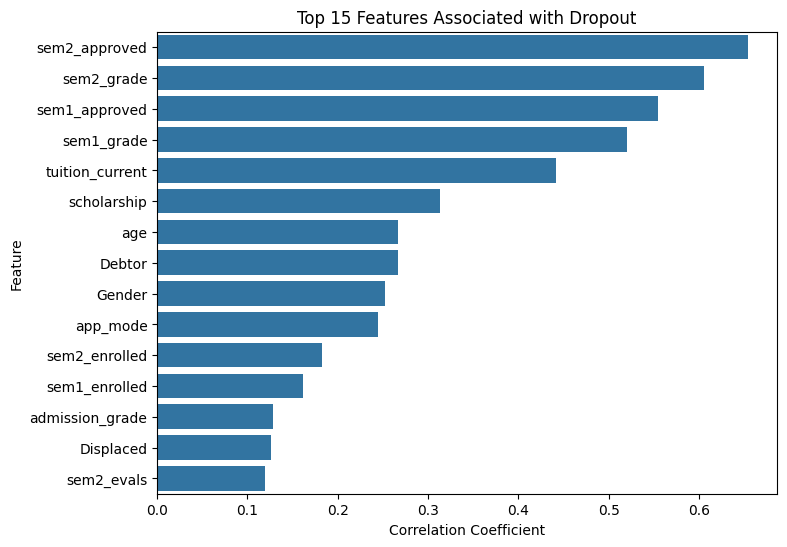

In [249]:
# Top 15 Most Correlated Features

target_corr = (
    corr_matrix["target"]
    .drop("target")
    .abs()
    .sort_values(ascending=False)
)

top15 = target_corr.head(15)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top15.values,
    y=top15.index
)

plt.title("Top 15 Features Associated with Dropout")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.show()

## Top 15 Most Correlated Features

This is particularly useful for identifying the most impactful features for prediction, regardless of the direction of their influence, as it tells you which features change most predictably with the target.


#Academic Variables
| Feature       | Correlation with Dropout |
| ------------- | -----------------------: |
| sem2_approved |                   -0.654 |
| sem2_grade    |                   -0.605 |
| sem1_approved |                   -0.555 |
| sem1_grade    |                   -0.520 |

# Interpretation
Students who:
- pass more courses,
- obtain higher semester grades,

are substantially less likely to drop out.


# Socioeconomic Variables

| Feature         | Correlation |
| --------------- | ----------: |
| tuition_current |      -0.442 |
| scholarship     |      -0.313 |
| Debtor          |      +0.267 |
| age             |      +0.267 |
| Gender          |      +0.252 |


#Interpretation

Students who:

- are up-to-date with tuition,
- have scholarships,

are more likely to graduate.

- Students who are debtors are more likely to drop out.

- Older students appear more likely to drop out.

      Possible reasons:

      - Work commitments
      - Family responsibilities
      - Returning to education after a gap


## **Insight (Hypothesis)**:
Academic performance indicators are stronger predictors of student dropout than demographic and socioeconomic characteristics.

**Age at Enrollment**

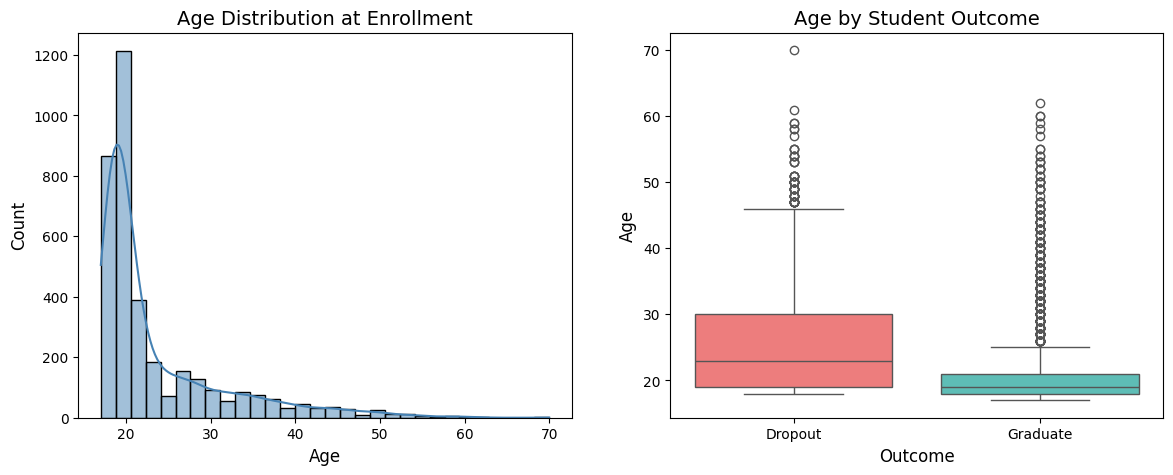

           count       mean       std   min   25%   50%   75%   max
target                                                             
Dropout   1421.0  26.068966  8.704024  18.0  19.0  23.0  30.0  70.0
Graduate  2209.0  21.783612  6.693218  17.0  18.0  19.0  21.0  62.0


In [250]:
# age at the enrollment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#ff6b6b','#4ecdc4',]
# Histogram
sns.histplot(data=df_eda, x='age', bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution at Enrollment', fontsize=14)
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)


# Boxplot by outcome
sns.boxplot(data=df_eda, x='target', y='age', ax=axes[1], palette=colors)
axes[1].set_title('Age by Student Outcome', fontsize=14)
axes[1].set_xlabel('Outcome', fontsize=12)
axes[1].set_ylabel('Age', fontsize=12)

# plt.tight_layout()
plt.show()


print(df_eda.groupby('target')['age'].describe())



# Interpretation
While younger students (18-30) dominate the dataset, they also show the highest dropout rates. Older students (30+) are fewer but appear more committed, they rarely drop out


# First semester grades

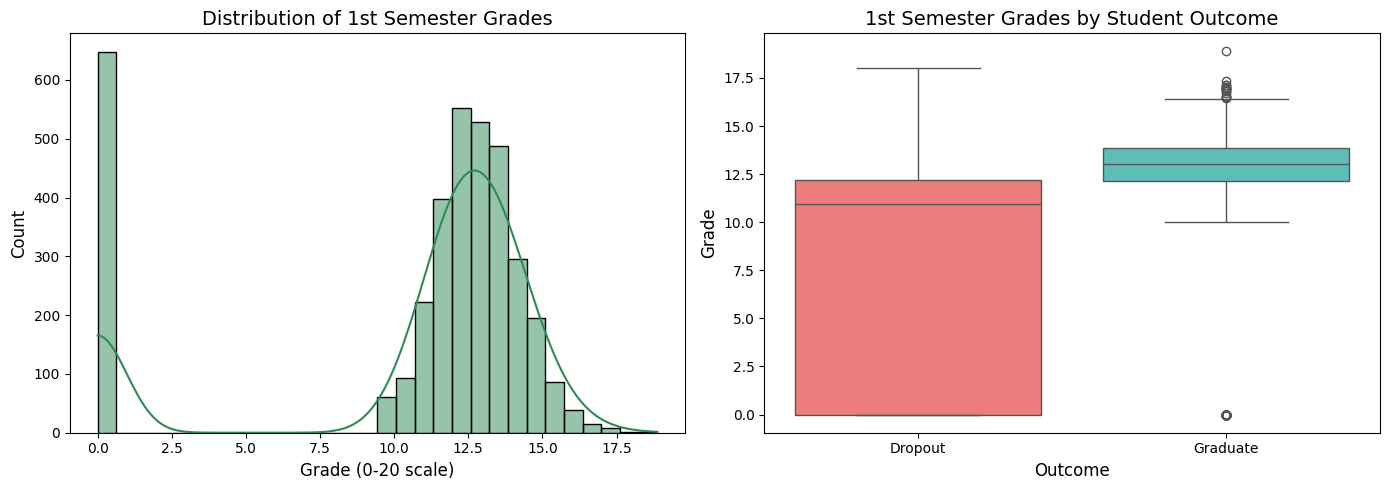

In [251]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(data=df_eda, x='sem1_grade', bins=30, kde=True, ax=axes[0], color='seagreen',)
axes[0].set_title('Distribution of 1st Semester Grades', fontsize=14)
axes[0].set_xlabel('Grade (0-20 scale)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Boxplot by outcome
sns.boxplot(data=df_eda, x='target', y='sem1_grade', ax=axes[1], palette=colors,hue='target', legend=False)
axes[1].set_title('1st Semester Grades by Student Outcome', fontsize=14)
axes[1].set_xlabel('Outcome', fontsize=12)
axes[1].set_ylabel('Grade', fontsize=12)

plt.tight_layout()
plt.show()


**Interpretetion of the grph **

# 2.Bivariate Analysis (Two Variables)

1. Students who eventually drop out have a median grade around 10–11, while not graduate have median around 13–14.

2. The distribution is nearly normal (bell-shaped), peaking between 10–14, meaning most students enter university with similar academic ability. However, dropouts show a wider spread with many students scoring below 10,



# Scholarship Status vs Outcome


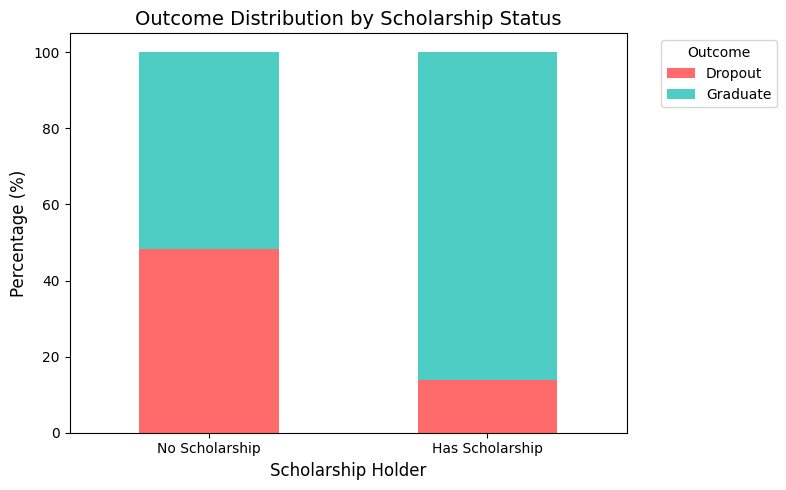

Scholarship vs Outcome (%):
target         Dropout   Graduate
scholarship                      
No           48.365276  51.634724
Yes          13.828689  86.171311


In [252]:
# Cross tabulation with percentages
scholarship_outcome = pd.crosstab(df_eda['scholarship'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
scholarship_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome Distribution by Scholarship Status', fontsize=14)
ax.set_xlabel('Scholarship Holder', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels(['No Scholarship', 'Has Scholarship'], rotation=0)
plt.tight_layout()
plt.show()

print("Scholarship vs Outcome (%):")
print(scholarship_outcome)

Interpretetion
1. Scholarship holders have a dramatically lower dropout rate  compared to non-scholarship students. dropout rates is very low around 12% for Scholarship holders whether dropout for non-scholarship is approximatelly 38%.

2. I think This is one of the strongest predictors in the dataset.

3. Expanding scholarship programs may be the single most effective intervention for reducing dropout.Every scholarship dollar appears to have a large impact


# 2 Debtor Status vs Outcome


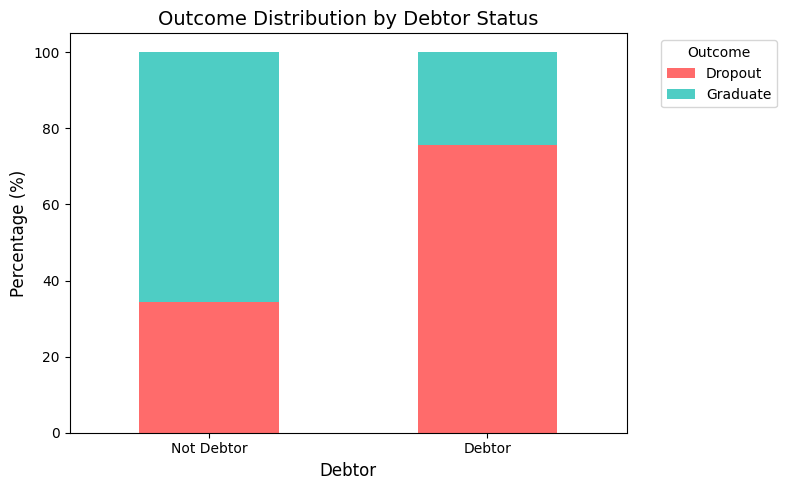

Debtor vs Outcome (%):
target    Dropout   Graduate
Debtor                      
No      34.473112  65.526888
Yes     75.544794  24.455206


In [253]:
debtor_outcome = pd.crosstab(
    df_eda['Debtor'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
debtor_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome Distribution by Debtor Status', fontsize=14)
ax.set_xlabel('Debtor', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels(['Not Debtor', 'Debtor'], rotation=0)
plt.tight_layout()
plt.show()

print("Debtor vs Outcome (%):")
print(debtor_outcome)

**Interpretation **
1. Debtors have a significantly higher dropout rate  compared to non-debtors

2. I can say Financial stress appears directly linked to leaving school.

3. Financial counseling and emergency aid programs should target identified debtors early. Even small financial interventions might prevent dropout for this group.

# 3. Marital Status vs Outcome


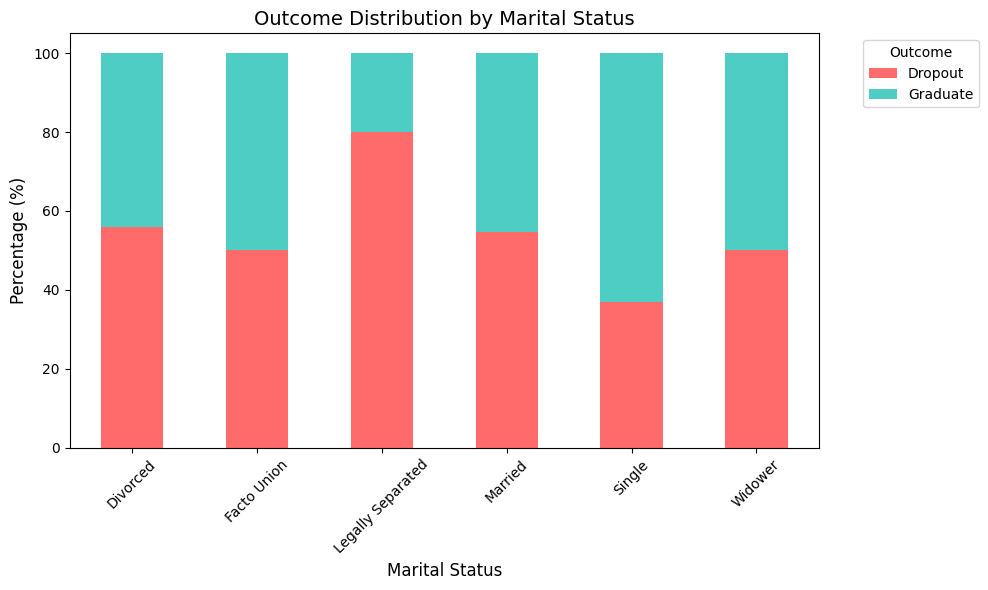

Marital Status vs Outcome (%):
target               Dropout   Graduate
marital_status                         
Divorced           56.000000  44.000000
Facto Union        50.000000  50.000000
Legally Separated  80.000000  20.000000
Married            54.740061  45.259939
Single             37.011566  62.988434
Widower            50.000000  50.000000


In [254]:
marital_outcome = pd.crosstab(df_eda['marital_status'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff6b6b','#4ecdc4',]
marital_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome Distribution by Marital Status', fontsize=14)
ax.set_xlabel('Marital Status', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Marital Status vs Outcome (%):")
print(marital_outcome)

Interpretation

1. Legally separated students tends to dropout more compared to another marital status

2.  single students show the lowest dropout.

3. the widower students tend to not dropout compared to another marital status

# Outcome analysis by Attendance



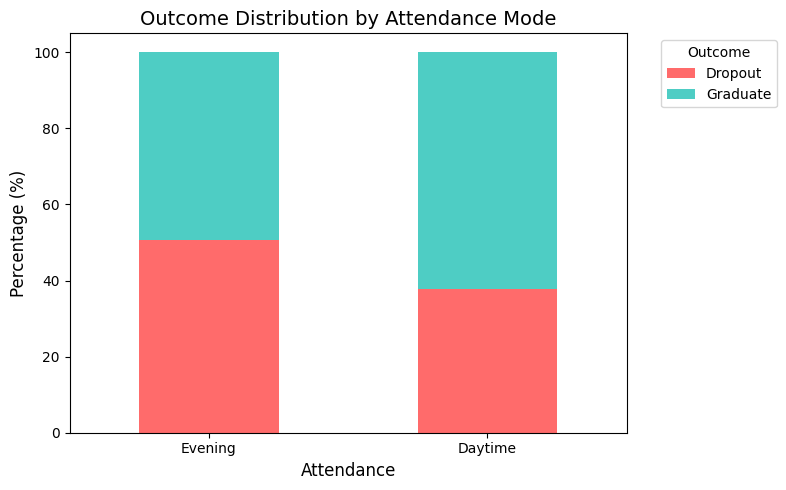

Attendance vs Outcome (%):
target                Dropout   Graduate
daytime_attendance                      
No                  50.735294  49.264706
Yes                 37.678461  62.321539


In [255]:
attendance_outcome = pd.crosstab(df_eda['daytime_attendance'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#ff6b6b','#4ecdc4',]
attendance_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome Distribution by Attendance Mode', fontsize=14)
ax.set_xlabel('Attendance', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels(['Evening', 'Daytime'], rotation=0)
plt.tight_layout()
plt.show()

print("Attendance vs Outcome (%):")
print(attendance_outcome)

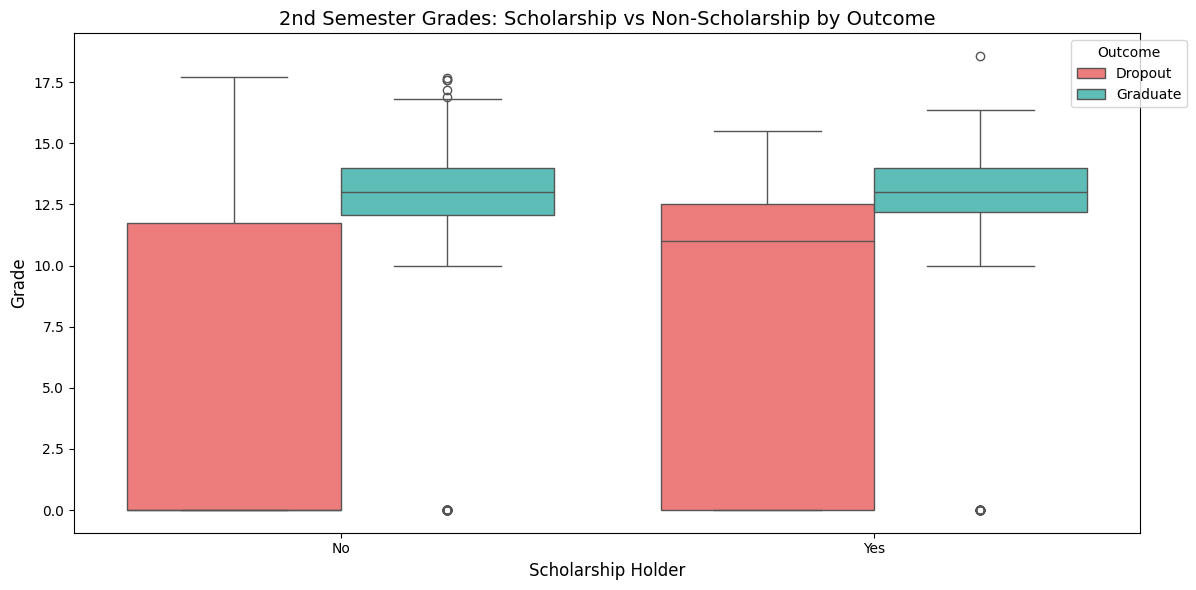

In [256]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_eda, x='scholarship', y='sem2_grade', hue='target', palette=colors)
plt.title('2nd Semester Grades: Scholarship vs Non-Scholarship by Outcome', fontsize=14)
plt.xlabel('Scholarship Holder', fontsize=12)
plt.ylabel('Grade', fontsize=12)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**Interpretation**

1. scholarship holders who drop out have grades nearly as low as non-scholarship dropouts which  means scholarship alone doesn't save a student with very poor performance.

# Analysis of outcome by age and grades


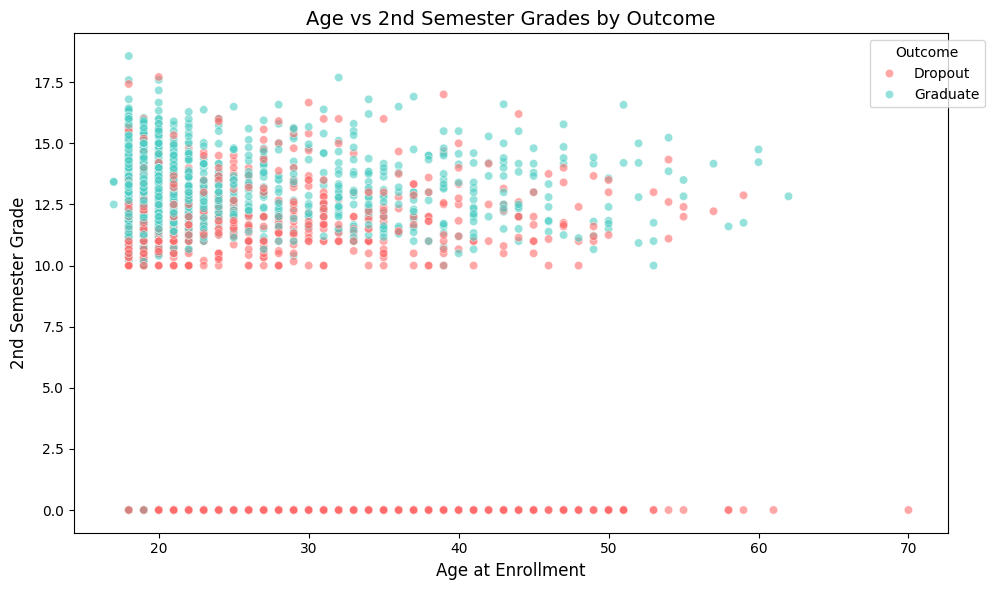

In [257]:
# ploting the outcome with age and grades

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='age', y='sem2_grade', hue='target', alpha=0.6, palette=colors)
plt.title('Age vs 2nd Semester Grades by Outcome', fontsize=14)
plt.xlabel('Age at Enrollment', fontsize=12)
plt.ylabel('2nd Semester Grade', fontsize=12)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()



**Interpretation**
1. as the most of our dataset are young peaple.

The scatter plot shows dropout students with younger age, lower grades below 10, Interestingly.


===========================================

# **4. Train/Test Split & Baseline Models**

4.1. Feature Engineering



In [258]:
df_model

,marital_status,app_mode,app_order,Course,daytime_attendance,prev_qual,prev_qual_grade,nationality,mother_qual,father_qual,...,sem2_credited,sem2_enrolled,sem2_evals,sem2_approved,sem2_grade,sem2_no_evals,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,0
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,1
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,1
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,0


4.2. Feature-Target Split

In [259]:
# Features and target
X = df_model.drop("target", axis=1)
y = df_model["target"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (3630, 36)
Target Shape: (3630,)


4.3. Train-Test Split

In [260]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (2904, 36)
Testing Set : (726, 36)


In [261]:
# Verify Class Distribution
print("Overall:")
print(y.value_counts(normalize=True))

print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Overall:
target
0    0.60854
1    0.39146
Name: proportion, dtype: float64

Train:
target
0    0.608471
1    0.391529
Name: proportion, dtype: float64

Test:
target
0    0.608815
1    0.391185
Name: proportion, dtype: float64


4.4. Feature Scaling

In [262]:
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(2904, 36)
(726, 36)


**4.5. Statistical Baseline: Dummy Classifier**

It is used as a baseline to determine whether more sophisticated models are actually adding predictive value. `Can we beat a model that does not learn anything?`

In [263]:
baseline_dummy = DummyClassifier(strategy='most_frequent')

baseline_dummy.fit(X_train_scaled, y_train)

baseline_dummy_pred = baseline_dummy.predict(X_test_scaled)

# Create a proper metrics dictionary (same structure as evaluate_model output)
baseline_dummy_scores = {
    "Accuracy": accuracy_score(y_test, baseline_dummy_pred),
    "Precision": precision_score(y_test, baseline_dummy_pred),
    "Recall": recall_score(y_test, baseline_dummy_pred),
    "F1": f1_score(y_test, baseline_dummy_pred),
    "ROC_AUC": roc_auc_score(y_test, baseline_dummy_pred),
    "Model": "DummyClassifier",
    "Experiment": "Baseline_Dummy"
}

# Convert it into DataFrame
results_baseline_dummy = pd.DataFrame([baseline_dummy_scores])
results_baseline_dummy

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.608815,0.0,0.0,0.0,0.5,DummyClassifier,Baseline_Dummy


**4.6. ML Baseline: Logistic Regression**

This is our first real machine learning model.

In [264]:

baseline_lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_lr.fit(X_train_scaled, y_train)

baseline_lr_pred = baseline_lr.predict(X_test_scaled)

# Create a proper metrics dictionary (same structure as evaluate_model output)
baseline_lr_scores = {
    "Accuracy": accuracy_score(y_test, baseline_lr_pred),
    "Precision": precision_score(y_test, baseline_lr_pred),
    "Recall": recall_score(y_test, baseline_lr_pred),
    "F1": f1_score(y_test, baseline_lr_pred),
    "ROC_AUC": roc_auc_score(y_test, baseline_lr_pred),
    "Model": "Logistic Regression",
    "Experiment": "Baseline_LogisticRegression"
}

# Convert it into DataFrame
results_baseline_lr = pd.DataFrame([baseline_lr_scores])
results_baseline_lr


,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.942149,0.932143,0.919014,0.925532,0.938014,Logistic Regression,Baseline_LogisticRegression


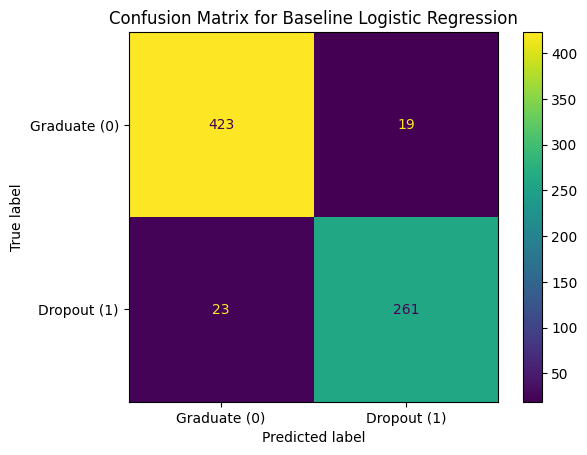

In [265]:
# Compute confusion matrix for baseline_lr
cm_baseline_lr = confusion_matrix(
    y_test,
    baseline_lr_pred
)

# Display confusion matrix visually
ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline_lr,
    display_labels=['Graduate (0)', 'Dropout (1)']
).plot()

plt.title('Confusion Matrix for Baseline Logistic Regression')
plt.show()

In [266]:
baseline_results = pd.DataFrame({
    "DummyClassifier": baseline_dummy_scores,
    "Logistic Regression": baseline_lr_scores
})

baseline_results.T

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
DummyClassifier,0.608815,0.0,0.0,0.0,0.5,DummyClassifier,Baseline_Dummy
Logistic Regression,0.942149,0.932143,0.919014,0.925532,0.938014,Logistic Regression,Baseline_LogisticRegression


# Interpretation:
A simple Log Reg using all features is already achieving high accuracy.

`Now, Can we achieve similar performance using fewer features?`



# **5. Feature Selection**

**To test the following hypothesis:**

H₀: Feature selection does not improve performance.

H₁: Feature selection can maintain or improve performance while reducing dimensionality.

1. Filter Method (SelectBest and Mutual Information)

In [267]:
from sklearn.feature_selection import f_classif

selector = SelectKBest(
    score_func=f_classif,
    k="all"
)

selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "F_Score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="F_Score",
    ascending=False
)

feature_scores.head(20)

,Feature,F_Score
30,sem2_approved,2152.676317
31,sem2_grade,1708.278133
24,sem1_approved,1287.563132
25,sem1_grade,1073.493875
16,tuition_current,688.692019
18,scholarship,334.808809
15,Debtor,227.742247
19,age,213.169297
17,Gender,203.520695
1,app_mode,167.568760


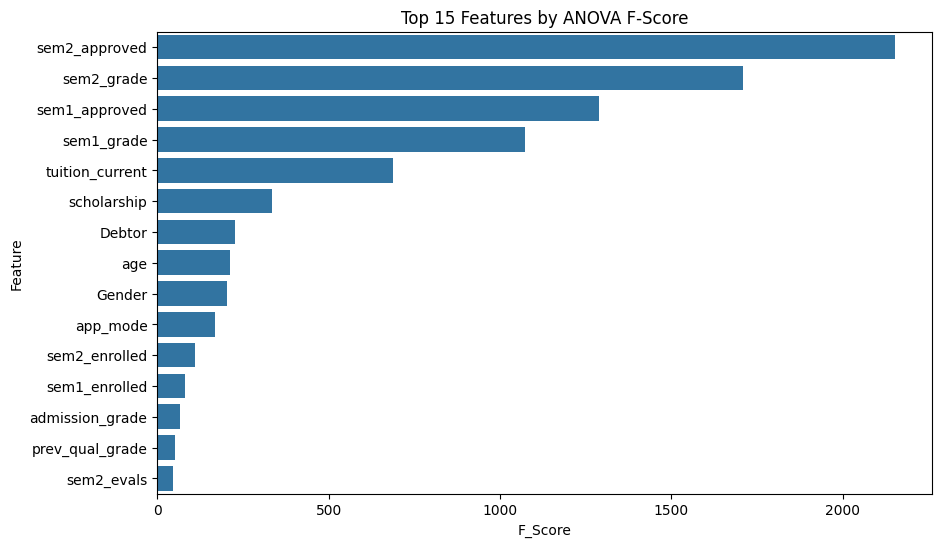

In [268]:
# Visualise Top Features BY ANOVA F-Score

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_scores.head(15),
    x="F_Score",
    y="Feature"
)

plt.title("Top 15 Features by ANOVA F-Score")
plt.show()

In [269]:
# Calculate MI scores
mi_scores = mutual_info_classif(
    X_train_scaled,
    y_train,
    random_state=42
    )

# Rank features
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

# Select top 15 features
top_features = mi_df.head(15)['Feature']
print(f"Top 15 Feature are:\n\n{top_features}")

Top 15 Feature are:

30      sem2_approved
24      sem1_approved
31         sem2_grade
25         sem1_grade
16    tuition_current
29         sem2_evals
23         sem1_evals
22      sem1_enrolled
18        scholarship
1            app_mode
28      sem2_enrolled
3              Course
19                age
15             Debtor
12    admission_grade
Name: Feature, dtype: object


In [270]:
import functools

# Select only to 15 best features based on mutual information
selector = SelectKBest(
    score_func=functools.partial(mutual_info_classif, random_state=42),
    k=15
)

X_train_filter = selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_filter = selector.transform(
    X_test_scaled
)

# Print selected features based on their score
scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print(scores.head(15))

            Feature     Score
30    sem2_approved  0.313862
24    sem1_approved  0.264053
31       sem2_grade  0.257687
25       sem1_grade  0.198333
16  tuition_current  0.097608
29       sem2_evals  0.090614
23       sem1_evals  0.074268
22    sem1_enrolled  0.060103
18      scholarship  0.059214
1          app_mode  0.052784
28    sem2_enrolled  0.050621
3            Course  0.049829
19              age  0.049312
15           Debtor  0.047035
12  admission_grade  0.037476


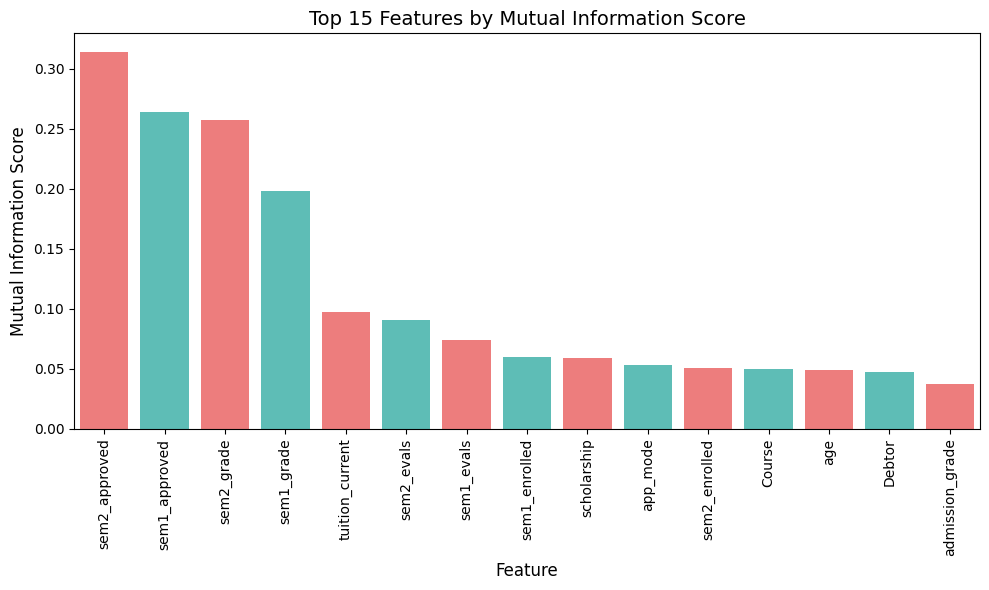

In [271]:
# plot a bar chart with feature name and the score
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Score', data=scores.head(15), palette=colors)
plt.title('Top 15 Features by Mutual Information Score', fontsize=14)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Mutual Information Score', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

===> Change K and compare

2. Wrapper Method (RFE)

In [272]:
rfe_model = LogisticRegression(
    max_iter=1000
)

rfe = RFE(
    estimator=rfe_model,
    n_features_to_select=15
)

X_train_rfe = rfe.fit_transform(
    X_train_scaled,
    y_train
)

X_test_rfe = rfe.transform(
    X_test_scaled
)

# print selected features
selected_features = X.columns[rfe.support_]
print(selected_features)

Index(['Course', 'nationality', 'Debtor', 'tuition_current', 'scholarship',
       'International', 'sem1_credited', 'sem1_enrolled', 'sem1_approved',
       'sem1_grade', 'sem1_no_evals', 'sem2_credited', 'sem2_enrolled',
       'sem2_approved', 'sem2_grade'],
      dtype='object')


In [273]:
df

,marital_status,app_mode,app_order,Course,daytime_attendance,prev_qual,prev_qual_grade,nationality,mother_qual,father_qual,...,sem2_credited,sem2_enrolled,sem2_evals,sem2_approved,sem2_grade,sem2_no_evals,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


3. Embedded Method

In [274]:
# Create a Random Forest classifier

rf_fs = RandomForestClassifier(
    random_state=42
)

# Train the model using the training data
rf_fs.fit(
    X_train,
    y_train
)

# Create a DataFrame containing:
# - Feature names
# - Their importance scores from the Random Forest
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_fs.feature_importances_
})

# Sort features by importance (highest first)
# and display the top 15 most important features
importance_df.sort_values(
    by='Importance',
    ascending=False
).head(15)

,Feature,Importance
30,sem2_approved,0.193466
31,sem2_grade,0.155805
24,sem1_approved,0.122326
25,sem1_grade,0.062056
16,tuition_current,0.051962
19,age,0.033839
29,sem2_evals,0.029861
12,admission_grade,0.027827
6,prev_qual_grade,0.026412
3,Course,0.026245


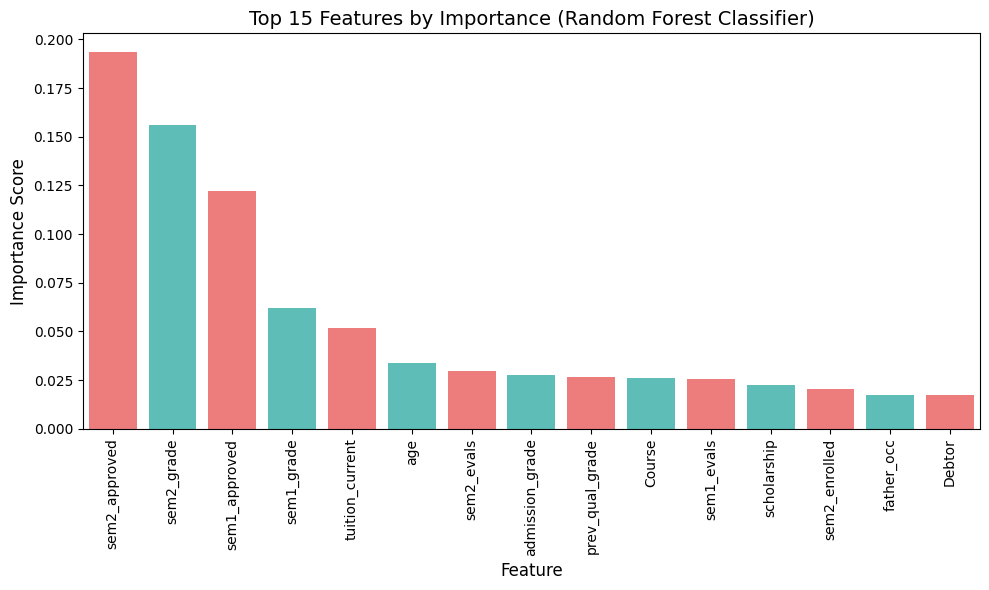

In [275]:
# Plot the most important features using bar chart with their importance
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Feature',
    y='Importance',
    data=importance_df.sort_values(
        by='Importance',
        ascending=False
    ).head(15),
    palette=colors
)
plt.title('Top 15 Features by Importance (Random Forest Classifier)', fontsize=14)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## PCA: Principal Component Analysis

In [276]:
pca = PCA()

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)



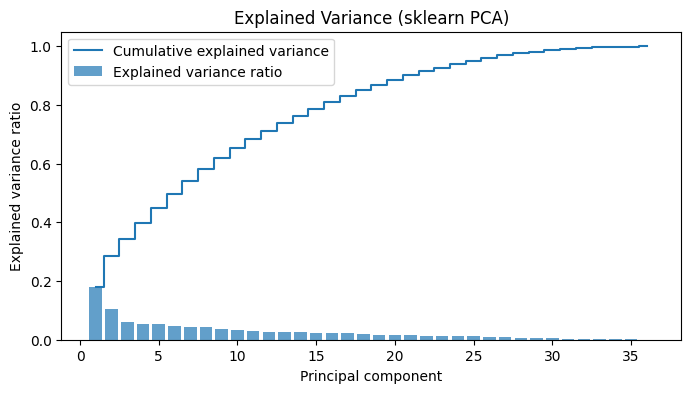

In [277]:
# Explained Variance
explained_variance = pca.explained_variance_ratio_

# Cumulative Explained Variance
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,4))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, label="Explained variance ratio")
plt.step(range(1, len(cumulative_variance)+1), cumulative_variance, where="mid", label="Cumulative explained variance")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Explained Variance (sklearn PCA)")
plt.legend()
plt.show()

In [278]:
# Retain 80% Variance
pca = PCA(n_components=0.80)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

print(
    "Components retained:",
    pca.n_components_
)

Components retained: 16


## **MODEL TRAINING FUNCTION**

In [279]:
#This function trains a classification model, makes predictions, calculates several evaluation metrics, and returns them in a dictionary.
# Function to train and evaluate a classification model
def evaluate_model(model,
                   X_train,
                   X_test,
                   y_train,
                   y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Predict class labels
    pred = model.predict(X_test)

    # Predict probabilities for positive class
    prob = model.predict_proba(X_test)[:, 1]

    # Return evaluation metrics
    return {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, prob)
    }

In [280]:
X_train.columns

Index(['marital_status', 'app_mode', 'app_order', 'Course',
       'daytime_attendance', 'prev_qual', 'prev_qual_grade', 'nationality',
       'mother_qual', 'father_qual', 'mother_occ', 'father_occ',
       'admission_grade', 'Displaced', 'special_needs', 'Debtor',
       'tuition_current', 'Gender', 'scholarship', 'age', 'International',
       'sem1_credited', 'sem1_enrolled', 'sem1_evals', 'sem1_approved',
       'sem1_grade', 'sem1_no_evals', 'sem2_credited', 'sem2_enrolled',
       'sem2_evals', 'sem2_approved', 'sem2_grade', 'sem2_no_evals',
       'unemployment_rate', 'inflation_rate', 'gdp'],
      dtype='object')

## **MODELS**

In [281]:
# Dictionary containing model names and model objects

models = {

    # Logistic Regression classifier
    # max_iter=1000 gives the optimizer more iterations to converge
    "Logistic Regression":
    LogisticRegression(
        max_iter=1000
    ),

    # Single Decision Tree classifier
    "Decision Tree":
    DecisionTreeClassifier(
        random_state=42
    ),

    # Random Forest classifier: Ensemble of many decision trees
    "Random Forest":
    RandomForestClassifier(
        random_state=42
    ),

    # XGBoost classifier
    # Powerful gradient boosting algorithm
    # eval_metric='logloss' specifies the evaluation metric during training
    "XGBoost":
    XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )
}

## **Experimentation**

In [282]:
# Experiment 1: Train models using ALL features

results_all = []  # store each model's results

for name, model in models.items():

    # Train model and compute metrics
    scores = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    # Add metadata for tracking
    scores["Model"] = name
    scores["Experiment"] = "All Features"

    # Store results
    results_all.append(scores)

# Convert list of dictionaries into DataFrame
results_all = pd.DataFrame(results_all)

# Show results
results_all

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.942149,0.932143,0.919014,0.925532,0.973305,Logistic Regression,All Features
1,0.847107,0.772871,0.862676,0.815308,0.849890,Decision Tree,All Features
2,0.921488,0.915751,0.880282,0.897666,0.970700,Random Forest,All Features
3,0.920110,0.906475,0.887324,0.896797,0.969744,XGBoost,All Features


In [283]:
# Experiment 2: Feature Selection (Mutual Information + SelectKBest)

results_fs = []  # store results for this experiment

# Loop through all models
for name, model in models.items():

    # Train model using selected features
    scores = evaluate_model(
        model,
        X_train_filter,
        X_test_filter,
        y_train,
        y_test
    )

    # Add metadata for tracking
    scores["Model"] = name
    scores["Experiment"] = "Mutual Information"

    # Store results
    results_fs.append(scores)

# Convert results to DataFrame
results_fs = pd.DataFrame(results_fs)

# Display results
results_fs

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.940771,0.941392,0.904930,0.922801,0.968573,Logistic Regression,Mutual Information
1,0.869146,0.820339,0.852113,0.835924,0.866102,Decision Tree,Mutual Information
2,0.921488,0.921933,0.873239,0.896926,0.964709,Random Forest,Mutual Information
3,0.915978,0.896797,0.887324,0.892035,0.963148,XGBoost,Mutual Information


In [284]:
# Experiment 3: Recursive Feature Elimination (RFE)

results_rfe = []  # store results for RFE experiment

for name, model in models.items():

    # Train model using RFE-selected features
    scores = evaluate_model(
        model,
        X_train_rfe,
        X_test_rfe,
        y_train,
        y_test
    )

    # Add metadata for tracking
    scores["Model"] = name
    scores["Experiment"] = "Recursive Feature Elimination (RFE)"

    # Store results
    results_rfe.append(scores)

# Convert list to DataFrame
results_rfe = pd.DataFrame(results_rfe)

# Display results
results_rfe

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.929752,0.905923,0.915493,0.910683,0.974301,Logistic Regression,Recursive Feature Elimination (RFE)
1,0.862259,0.782209,0.897887,0.836066,0.876788,Decision Tree,Recursive Feature Elimination (RFE)
2,0.922865,0.893103,0.911972,0.902439,0.972671,Random Forest,Recursive Feature Elimination (RFE)
3,0.921488,0.887372,0.915493,0.901213,0.968740,XGBoost,Recursive Feature Elimination (RFE)


In [285]:
# Experiment 4: Principal Component Analysis (PCA)

results_pca = []  # store PCA experiment results

# Loop through each model
for name, model in models.items():

    # Train model using PCA-transformed features
    scores = evaluate_model(
        model,
        X_train_pca,
        X_test_pca,
        y_train,
        y_test
    )

    # Add metadata for tracking
    scores["Model"] = name
    scores["Experiment"] = "Principal Component Analysis (PCA)"

    # Store results
    results_pca.append(scores)

# Convert results into DataFrame
results_pca = pd.DataFrame(results_pca)

# Display results
results_pca

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.914601,0.917293,0.859155,0.887273,0.955707,Logistic Regression,Principal Component Analysis (PCA)
1,0.809917,0.744966,0.781690,0.762887,0.804872,Decision Tree,Principal Component Analysis (PCA)
2,0.881543,0.892857,0.792254,0.839552,0.952158,Random Forest,Principal Component Analysis (PCA)
3,0.893939,0.884758,0.838028,0.860759,0.949621,XGBoost,Principal Component Analysis (PCA)


## **Model** **comparison**

In [286]:
# Combine the results from all experiments into one DataFrame
comparison = pd.concat([
    baseline_results.T,  # Baseline (DummyClassifier)
    results_all,    # Experiment 1: All Features
    results_fs,     # Experiment 2: Mutual Information Feature Selection
    results_rfe,    # Experiment 3: Recursive Feature Elimination (RFE)
    results_pca     # Experiment 4: Principal Component Analysis (PCA)
], ignore_index=True)

# Display the combined results
comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.608815,0.0,0.0,0.0,0.5,DummyClassifier,Baseline_Dummy
1,0.942149,0.932143,0.919014,0.925532,0.938014,Logistic Regression,Baseline_LogisticRegression
2,0.942149,0.932143,0.919014,0.925532,0.973305,Logistic Regression,All Features
3,0.847107,0.772871,0.862676,0.815308,0.84989,Decision Tree,All Features
4,0.921488,0.915751,0.880282,0.897666,0.9707,Random Forest,All Features
5,0.92011,0.906475,0.887324,0.896797,0.969744,XGBoost,All Features
6,0.940771,0.941392,0.90493,0.922801,0.968573,Logistic Regression,Mutual Information
7,0.869146,0.820339,0.852113,0.835924,0.866102,Decision Tree,Mutual Information
8,0.921488,0.921933,0.873239,0.896926,0.964709,Random Forest,Mutual Information
9,0.915978,0.896797,0.887324,0.892035,0.963148,XGBoost,Mutual Information


In [287]:
comparison.sort_values(
    by='F1',   # balance between precision & recall - Balanced classification
    ascending=False
).head(3)

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
2,0.942149,0.932143,0.919014,0.925532,0.973305,Logistic Regression,All Features
1,0.942149,0.932143,0.919014,0.925532,0.938014,Logistic Regression,Baseline_LogisticRegression
6,0.940771,0.941392,0.90493,0.922801,0.968573,Logistic Regression,Mutual Information


In [288]:
comparison.sort_values(by='ROC_AUC', ascending=False).head(3) # ranking ability

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
10,0.929752,0.905923,0.915493,0.910683,0.974301,Logistic Regression,Recursive Feature Elimination (RFE)
2,0.942149,0.932143,0.919014,0.925532,0.973305,Logistic Regression,All Features
12,0.922865,0.893103,0.911972,0.902439,0.972671,Random Forest,Recursive Feature Elimination (RFE)


In [289]:
comparison.sort_values(by='Accuracy', ascending=False).head(3)

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
2,0.942149,0.932143,0.919014,0.925532,0.973305,Logistic Regression,All Features
1,0.942149,0.932143,0.919014,0.925532,0.938014,Logistic Regression,Baseline_LogisticRegression
6,0.940771,0.941392,0.90493,0.922801,0.968573,Logistic Regression,Mutual Information


In [290]:
comparison.sort_values(by='Precision', ascending=False).head(3)

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
6,0.940771,0.941392,0.90493,0.922801,0.968573,Logistic Regression,Mutual Information
2,0.942149,0.932143,0.919014,0.925532,0.973305,Logistic Regression,All Features
1,0.942149,0.932143,0.919014,0.925532,0.938014,Logistic Regression,Baseline_LogisticRegression


In [291]:
comparison.sort_values(by='Recall', ascending=False).head(3)

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
2,0.942149,0.932143,0.919014,0.925532,0.973305,Logistic Regression,All Features
1,0.942149,0.932143,0.919014,0.925532,0.938014,Logistic Regression,Baseline_LogisticRegression
10,0.929752,0.905923,0.915493,0.910683,0.974301,Logistic Regression,Recursive Feature Elimination (RFE)


## **Tuning the best model based on F1**

In [292]:

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       442
           1       0.92      0.90      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.93       726
weighted avg       0.93      0.93      0.93       726



In [293]:
rf = RandomForestClassifier(
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [10, 20, None],   # Maximum depth of the tree
    'min_samples_split': [2, 5, 10] # Minimum number of samples required to split an internal node
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

best_rf_model = grid_rf.best_estimator_

y_pred_rf = best_rf_model.predict(X_test_scaled)

print("Best parameters for Random Forest:", grid_rf.best_params_)
print("\nClassification Report for Tuned Random Forest:")
print(classification_report(y_test, y_pred_rf))

Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

Classification Report for Tuned Random Forest:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       442
           1       0.93      0.87      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726



In [294]:
log_reg = LogisticRegression(
    max_iter=1000, # Ensure convergence
    random_state=42
)

param_grid_log_reg = {
    'C': [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'solver': ['liblinear', 'lbfgs'] # Solvers that work with L2 regularization
}

grid_log_reg = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_log_reg,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_log_reg.fit(X_train_scaled, y_train)

best_log_reg_model = grid_log_reg.best_estimator_

y_pred_log_reg = best_log_reg_model.predict(X_test_scaled)

print("Best parameters for Logistic Regression:", grid_log_reg.best_params_)
print("\nClassification Report for Tuned Logistic Regression:")
print(classification_report(y_test, y_pred_log_reg))

Best parameters for Logistic Regression: {'C': 1, 'solver': 'lbfgs'}

Classification Report for Tuned Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       442
           1       0.93      0.92      0.93       284

    accuracy                           0.94       726
   macro avg       0.94      0.94      0.94       726
weighted avg       0.94      0.94      0.94       726



In [295]:
dtree = DecisionTreeClassifier(
    random_state=42
)

param_grid_dtree = {
    'max_depth': [10, 20, 30, None], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]    # Minimum number of samples required to be at a leaf node
}

grid_dtree = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid_dtree,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_dtree.fit(X_train_scaled, y_train)

best_dtree_model = grid_dtree.best_estimator_

y_pred_dtree = best_dtree_model.predict(X_test_scaled)

print("Best parameters for Decision Tree:", grid_dtree.best_params_)
print("\nClassification Report for Tuned Decision Tree:")
print(classification_report(y_test, y_pred_dtree))

Best parameters for Decision Tree: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

Classification Report for Tuned Decision Tree:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       442
           1       0.84      0.85      0.84       284

    accuracy                           0.88       726
   macro avg       0.87      0.87      0.87       726
weighted avg       0.88      0.88      0.88       726



In [296]:
# Re-evaluate tuned models to get all metrics consistently

# Tuned XGBoost
metrics_tuned_xgb = evaluate_model(best_model, X_train_scaled, X_test_scaled, y_train, y_test)
metrics_tuned_xgb["Model"] = "XGBoost (Tuned)"
metrics_tuned_xgb["Experiment"] = "Tuned"

# Tuned Random Forest
metrics_tuned_rf = evaluate_model(best_rf_model, X_train_scaled, X_test_scaled, y_train, y_test)
metrics_tuned_rf["Model"] = "Random Forest (Tuned)"
metrics_tuned_rf["Experiment"] = "Tuned"

# Tuned Logistic Regression
metrics_tuned_log_reg = evaluate_model(best_log_reg_model, X_train_scaled, X_test_scaled, y_train, y_test)
metrics_tuned_log_reg["Model"] = "Logistic Regression (Tuned)"
metrics_tuned_log_reg["Experiment"] = "Tuned"

# Tuned Decision Tree
metrics_tuned_dtree = evaluate_model(best_dtree_model, X_train_scaled, X_test_scaled, y_train, y_test)
metrics_tuned_dtree["Model"] = "Decision Tree (Tuned)"
metrics_tuned_dtree["Experiment"] = "Tuned"

# Create DataFrames for tuned models
df_tuned_xgb = pd.DataFrame([metrics_tuned_xgb])
df_tuned_rf = pd.DataFrame([metrics_tuned_rf])
df_tuned_log_reg = pd.DataFrame([metrics_tuned_log_reg])
df_tuned_dtree = pd.DataFrame([metrics_tuned_dtree])

# Combine all results
full_comparison = pd.concat([
    comparison,
    df_tuned_xgb,
    df_tuned_rf,
    df_tuned_log_reg,
    df_tuned_dtree
], ignore_index=True)

# Display the full comparison, sorted by F1 score
print("\nFull Model Comparison (Sorted by F1 Score):\n")
print(full_comparison.sort_values(by='F1', ascending=False))




Full Model Comparison (Sorted by F1 Score):

    Accuracy Precision    Recall        F1   ROC_AUC  \
2   0.942149  0.932143  0.919014  0.925532  0.973305   
20  0.942149  0.932143  0.919014  0.925532  0.973305   
1   0.942149  0.932143  0.919014  0.925532  0.938014   
6   0.940771  0.941392   0.90493  0.922801  0.968573   
10  0.929752  0.905923  0.915493  0.910683  0.974301   
18  0.929752  0.920578  0.897887  0.909091   0.97066   
12  0.922865  0.893103  0.911972  0.902439  0.972671   
13  0.921488  0.887372  0.915493  0.901213   0.96874   
19  0.922865  0.931818  0.866197   0.89781  0.971186   
4   0.921488  0.915751  0.880282  0.897666    0.9707   
8   0.921488  0.921933  0.873239  0.896926  0.964709   
5    0.92011  0.906475  0.887324  0.896797  0.969744   
9   0.915978  0.896797  0.887324  0.892035  0.963148   
14  0.914601  0.917293  0.859155  0.887273  0.955707   
17  0.893939  0.884758  0.838028  0.860759  0.949621   
21   0.87741  0.842105   0.84507  0.843585  0.860414   
16

In [297]:
print("\nFull Model Comparison (Sorted by ROC_AUC Score):\n")
print(full_comparison.sort_values(by='ROC_AUC', ascending=False))




Full Model Comparison (Sorted by ROC_AUC Score):

    Accuracy Precision    Recall        F1   ROC_AUC  \
10  0.929752  0.905923  0.915493  0.910683  0.974301   
2   0.942149  0.932143  0.919014  0.925532  0.973305   
20  0.942149  0.932143  0.919014  0.925532  0.973305   
12  0.922865  0.893103  0.911972  0.902439  0.972671   
19  0.922865  0.931818  0.866197   0.89781  0.971186   
4   0.921488  0.915751  0.880282  0.897666    0.9707   
18  0.929752  0.920578  0.897887  0.909091   0.97066   
5    0.92011  0.906475  0.887324  0.896797  0.969744   
13  0.921488  0.887372  0.915493  0.901213   0.96874   
6   0.940771  0.941392   0.90493  0.922801  0.968573   
8   0.921488  0.921933  0.873239  0.896926  0.964709   
9   0.915978  0.896797  0.887324  0.892035  0.963148   
14  0.914601  0.917293  0.859155  0.887273  0.955707   
16  0.881543  0.892857  0.792254  0.839552  0.952158   
17  0.893939  0.884758  0.838028  0.860759  0.949621   
1   0.942149  0.932143  0.919014  0.925532  0.938014 

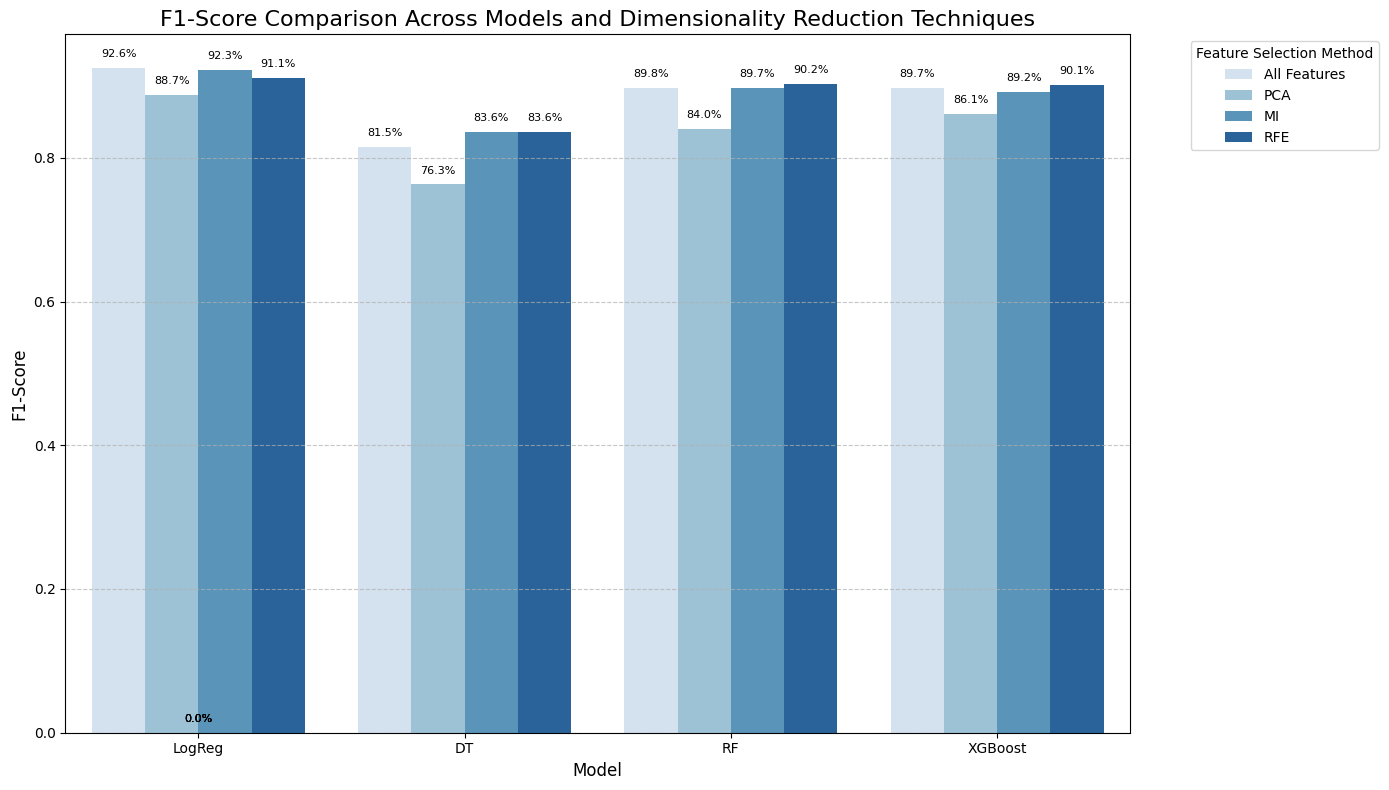

In [298]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out 'Baseline' and 'Tuned' experiments for this comparison
comparison_filtered = full_comparison[~full_comparison['Experiment'].isin(['Baseline', 'Tuned'])].copy()

# Map Model names for cleaner display on the plot
model_name_map = {
    'Logistic Regression': 'LogReg',
    'Decision Tree': 'DT',
    'Random Forest': 'RF',
    'XGBoost': 'XGBoost'
}
comparison_filtered['Model'] = comparison_filtered['Model'].map(model_name_map)

# Map Experiment names for cleaner display on the plot and consistent ordering
experiment_order = {
    'All Features': 'All Features',
    'Principal Component Analysis (PCA)': 'PCA',
    'Mutual Information': 'MI',
    'Recursive Feature Elimination (RFE)': 'RFE'
}
comparison_filtered['Experiment'] = comparison_filtered['Experiment'].map(experiment_order)

# Ensure the order of experiments in the plot
comparison_filtered['Experiment'] = pd.Categorical(
    comparison_filtered['Experiment'],
    categories=['All Features', 'PCA', 'MI', 'RFE'],
    ordered=True
)

plt.figure(figsize=(14, 8)) # Increased figure size for better readability of labels
ax = sns.barplot(
    data=comparison_filtered,
    x='Model',
    y='F1',
    hue='Experiment',
    palette='Blues' # Changed color palette to 'Blues'
)

# Add percentage of F1 score at the top of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()*100:.1f}%', # Format as percentage with one decimal place
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', xytext=(0, 10), textcoords='offset points',
        fontsize=8, color='black' # Smaller font and black color for better readability
    )

plt.title('F1-Score Comparison Across Models and Dimensionality Reduction Techniques', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.legend(title='Feature Selection Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

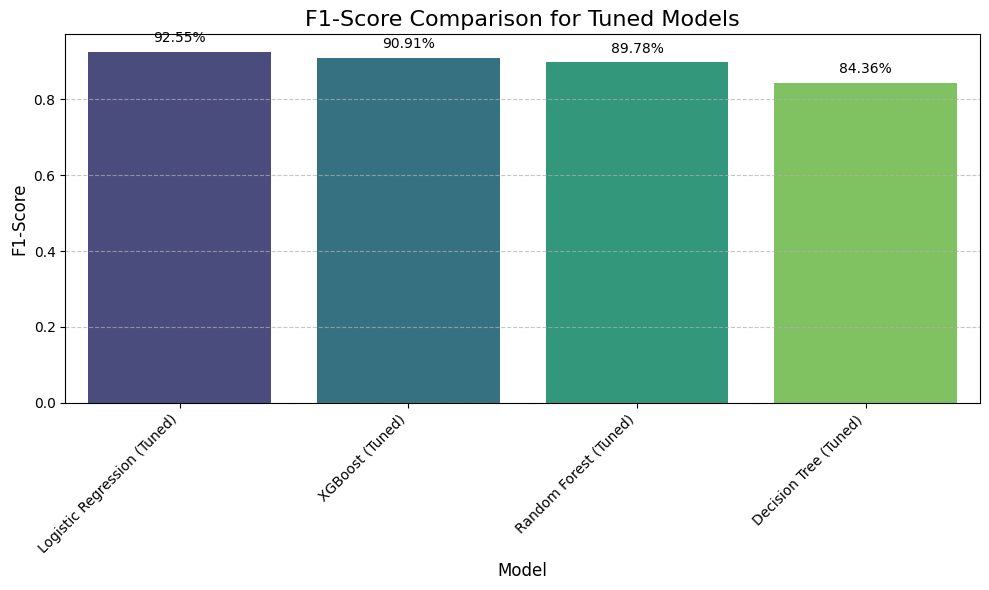

In [299]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for tuned models only
tuned_models_comparison = full_comparison[full_comparison['Experiment'] == 'Tuned'].copy()

# Sort by F1 score for better visualization
tuned_models_comparison = tuned_models_comparison.sort_values(by='F1', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=tuned_models_comparison,
    x='Model',
    y='F1',
    palette='viridis' # Choose a color palette
)

# Add percentage of F1 score at the top of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()*100:.2f}%', # Format as percentage with two decimal places
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', xytext=(0, 10), textcoords='offset points',
        fontsize=10, color='black'
    )

plt.title('F1-Score Comparison for Tuned Models', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

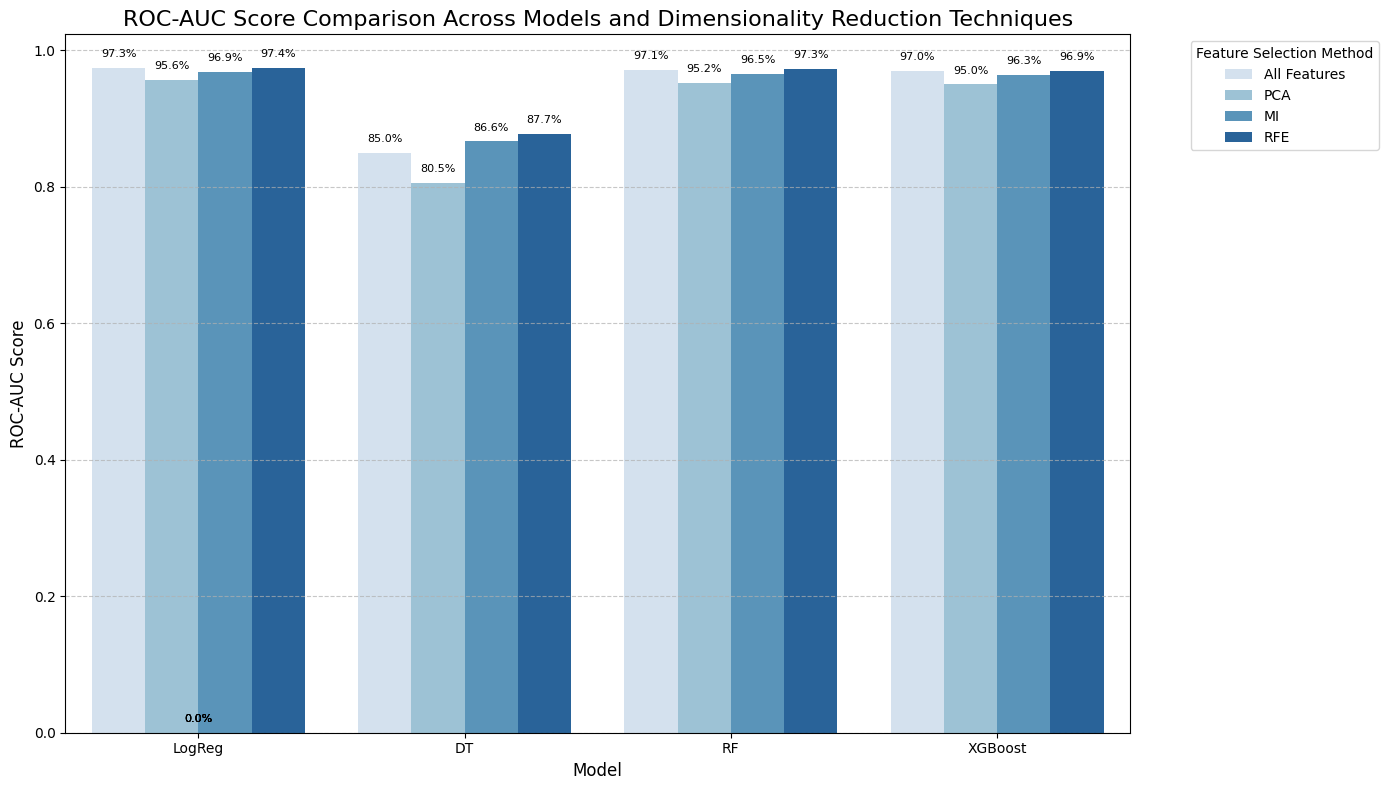

In [300]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out 'Baseline' and 'Tuned' experiments for this comparison
comparison_filtered = full_comparison[~full_comparison['Experiment'].isin(['Baseline', 'Tuned'])].copy()

# Map Model names for cleaner display on the plot
model_name_map = {
    'Logistic Regression': 'LogReg',
    'Decision Tree': 'DT',
    'Random Forest': 'RF',
    'XGBoost': 'XGBoost'
}
comparison_filtered['Model'] = comparison_filtered['Model'].map(model_name_map)

# Map Experiment names for cleaner display on the plot and consistent ordering
experiment_order = {
    'All Features': 'All Features',
    'Principal Component Analysis (PCA)': 'PCA',
    'Mutual Information': 'MI',
    'Recursive Feature Elimination (RFE)': 'RFE'
}
comparison_filtered['Experiment'] = comparison_filtered['Experiment'].map(experiment_order)

# Ensure the order of experiments in the plot
comparison_filtered['Experiment'] = pd.Categorical(
    comparison_filtered['Experiment'],
    categories=['All Features', 'PCA', 'MI', 'RFE'],
    ordered=True
)

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=comparison_filtered,
    x='Model',
    y='ROC_AUC',
    hue='Experiment',
    palette='Blues' # Changed color palette to 'Blues'
)

# Add percentage of ROC_AUC score at the top of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()*100:.1f}%', # Format as percentage with one decimal place
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', xytext=(0, 10), textcoords='offset points',
        fontsize=8, color='black' # Smaller font and black color for better readability
    )

plt.title('ROC-AUC Score Comparison Across Models and Dimensionality Reduction Techniques', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.legend(title='Feature Selection Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Confusion Matrix**

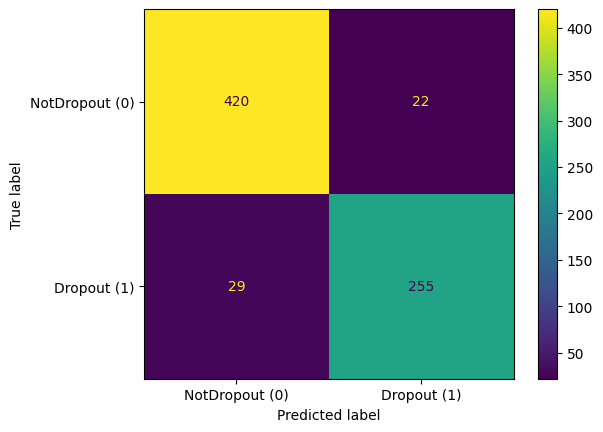

In [301]:
# Get the best model from GridSearchCV
best_log_reg_model = grid.best_estimator_

# Make predictions on the test set
pred = best_log_reg_model.predict(
    X_test_scaled
)

# Compute confusion matrix
cm = confusion_matrix(
    y_test,
    pred
)

# Display confusion matrix visually
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['NotDropout (0)', 'Dropout (1)']
).plot()

# Show the plot
plt.show()

In [302]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

## **Feature Importance**

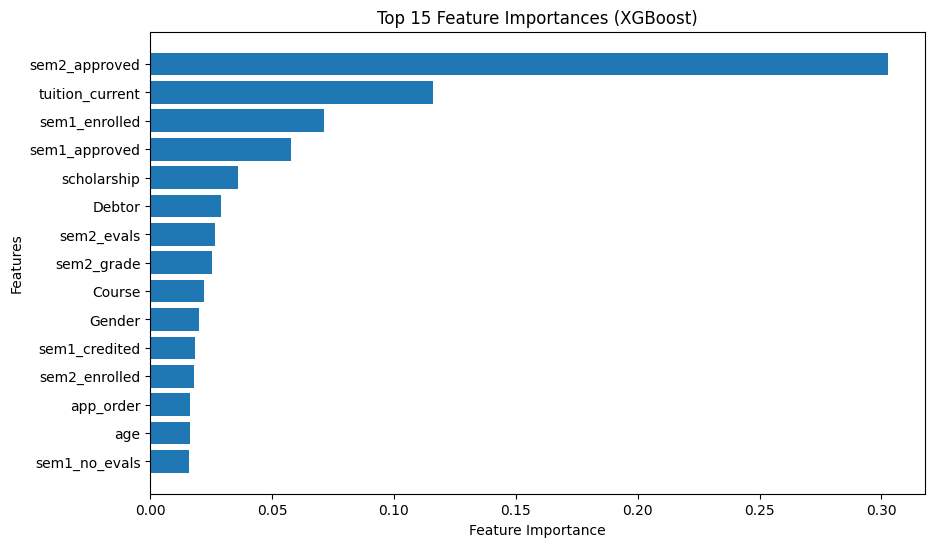

In [303]:
# Sort and take top 15 features
top_features = importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

# Plot
plt.figure(figsize=(10,6))
plt.barh(
    top_features['Feature'][::-1],      # reverse for descending order
    top_features['Importance'][::-1]
)

# Labels and title
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.show()

=====================================
